In [40]:
#Used for data manipulation and analysis.
import pandas as pd
#Used for working with arrays
import numpy as np
#Used for visualizations. 
import matplotlib.pyplot as plt
# primary library for machine learning algorithms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the Churn Modelling datase

In [83]:
# loading data set 
df=pd.read_csv(r'C:\Users\EB\Downloads\Churn_Modelling.csv')

# 2 DATA CLEANING

In [21]:
#detect missing values

In [22]:
df.isna()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9996,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9997,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9998,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [84]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [23]:
#count the number of missing values

In [24]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [25]:
# Drop irrelevant Columns features that don't required

In [27]:
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 3 Encode categorical features such as geography and gender.

In [28]:
# Encode 'Gender' into 0 and 1
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
# One-Hot Encode Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# 4 Training a classification model.

In [74]:
# Define Features (X) and Target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']
# Split into 80% Training and 20% Testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# MODEL TRAINING 
# we use RandomForest for higher accuracy. 
model = RandomForestClassifier(n_estimators=100 ,random_state=42)
model.fit(X_train, y_train)
# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")


Accuracy: 0.87


In [76]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

model_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model_smote.fit(X_train_sm, y_train_sm)
y_pred_sm = model_smote.predict(X_test)

print(classification_report(y_test, y_pred_sm))

              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1607
           1       0.56      0.64      0.60       393

    accuracy                           0.83      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.84      0.83      0.83      2000



In [71]:
#Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))



Confusion Matrix:
[[1552   55]
 [ 213  180]]


In [78]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



# 4 analyzing feature.

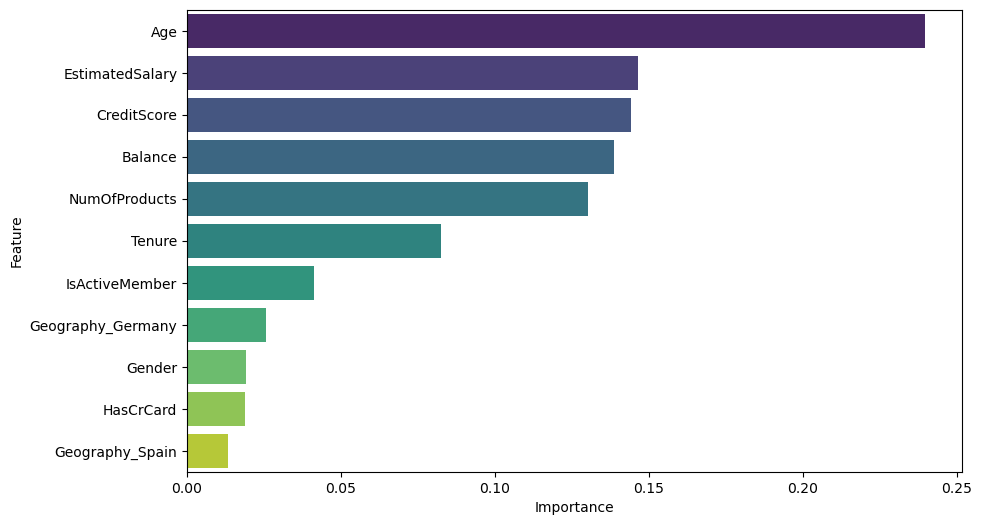

In [36]:
# Get feature importance scores
importances = model.feature_importances_
feature_names = X.columns
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)
# Plot the top factors
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df, hue='Feature', palette='viridis', legend=False)
plt.show()